#### Error Analysis & SHAP

**Inputs used (produced by `05_Multitarget_forecasting.ipynb`):**
- `results/validation_month_9_predictions.csv` — actual vs Baseline/RF/LightGBM predictions (Month 9 → 10)
- `results/month_11_forecast.csv` — final forecast (Month 10 → 11)
- `results/lightgbm_best_params.json` — tuned hyperparameters, so the model doesn't need re-tuning
- `data/all_months_features.csv` — original data, needed for Category/Unit labels and SHAP features

No hyperparameter search is repeated here — only a quick refit with the saved best params, since SHAP needs the actual fitted model, not just prediction CSVs.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb

from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
RANDOM_STATE = 42
targets_next = ["Min_Price_next", "Avg_Price_next", "Max_Price_next"]

/Users/bruker/Desktop/Multi-Target Price Forecasting /.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Load Required Files

In [2]:
validation_results = pd.read_csv("results/validation_month_9_predictions.csv")
forecast_df = pd.read_csv("results/month_11_forecast.csv")

with open("results/lightgbm_best_params.json") as f:
    lgb_params = json.load(f)

print(f"Validation rows : {len(validation_results)}")
print(f"Forecast rows   : {len(forecast_df)}")
print("Loaded tuned LightGBM params:", lgb_params)

Validation rows : 49
Forecast rows   : 95
Loaded tuned LightGBM params: {'n_estimators': 600, 'learning_rate': 0.011824170189213168, 'num_leaves': 14, 'max_depth': 14, 'min_child_samples': 24, 'subsample': 0.7747587795413311, 'colsample_bytree': 0.6859229318112912, 'reg_alpha': 0.0008732367520347047, 'reg_lambda': 4.59180931301918e-08, 'random_state': 42, 'n_jobs': -1, 'verbosity': -1}


#### Rebuild Features (same steps as Notebook 05)
Only needed to (a) attach Category/Unit for the error breakdown and (b) refit LightGBM for SHAP.

In [3]:
df = pd.read_csv("data/all_months_features.csv")
df = df.sort_values(["Product_Name"]).reset_index(drop=True)
df["month_idx"] = df.groupby("Product_Name").cumcount() + 1
df = df.sort_values(["Product_Name", "month_idx"]).reset_index(drop=True)

targets_base = ["Min_Price", "Avg_Price", "Max_Price"]
for base, nxt in zip(targets_base, targets_next):
    df[nxt] = df.groupby("Product_Name")[base].shift(-1)

train_df = df[df["month_idx"] <= 8].dropna(subset=targets_next).copy()
valid_df = df[df["month_idx"] == 9].dropna(subset=targets_next).copy()

non_feature_cols = ["Product_Name", "Category", "Unit", "unit_canonical", "month_name",
                     "bs_year", "bs_month", "month_idx",
                     "Total_Amount"] + targets_base + targets_next  # Total_Amount = Volume x current Avg_Price -> leakage
feature_cols = [c for c in df.columns if c not in non_feature_cols]

X_train = train_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y_train = train_df[targets_next]
X_valid = valid_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

print(f"X_train: {X_train.shape} | X_valid: {X_valid.shape}")

X_train: (591, 65) | X_valid: (48, 65)


In [4]:
# Attach Category/Unit to the validation predictions (not saved in 05's CSV)
validation_results = validation_results.merge(
    valid_df[["Product_Name", "Category", "Unit"]], on="Product_Name", how="left"
)
print(validation_results.head(3).to_string(index=False))

Product_Name  month_idx  Actual_Min_Price_next  Baseline_Min_Price_next  RF_Min_Price_next  LightGBM_Min_Price_next  Actual_Avg_Price_next  Baseline_Avg_Price_next  RF_Avg_Price_next  LightGBM_Avg_Price_next  Actual_Max_Price_next  Baseline_Max_Price_next  RF_Max_Price_next  LightGBM_Max_Price_next  Category Unit
       Apple          9                  225.0                    225.0             214.54                   230.66                 266.30                    255.0             259.75                   273.41                  350.0                    330.0             327.77                   319.22     fruit   kg
        Arum          9                   60.0                     60.0              68.56                    52.23                  65.00                     70.0              80.70                    52.23                   70.0                     80.0              90.33                    72.20 vegetable   kg
     Avocado          9                  650.0         

#### Category-Wise Error (RF vs LightGBM)

In [5]:
category_results = []
for category in validation_results["Category"].dropna().unique():
    mask = validation_results["Category"] == category
    for target in targets_next:
        actual = validation_results.loc[mask, f"Actual_{target}"]
        category_results.append({
            "Category": category, "Target": target,
            "RF MAE": mean_absolute_error(actual, validation_results.loc[mask, f"RF_{target}"]),
            "LightGBM MAE": mean_absolute_error(actual, validation_results.loc[mask, f"LightGBM_{target}"])
        })

category_error_df = pd.DataFrame(category_results).round(2)
category_error_df.to_csv("results/category_wise_error.csv", index=False)

print("Saved: results/category_wise_error.csv")
print(category_error_df.to_string(index=False))

Saved: results/category_wise_error.csv
 Category         Target  RF MAE  LightGBM MAE
    fruit Min_Price_next   49.20         50.37
    fruit Avg_Price_next   67.53         65.81
    fruit Max_Price_next   78.33         74.66
vegetable Min_Price_next   23.07         20.03
vegetable Avg_Price_next   26.84         20.80
vegetable Max_Price_next   28.94         17.79


#### Unit-Wise Error (RF vs LightGBM)

In [6]:
unit_results = []
for unit in validation_results["Unit"].dropna().unique():
    mask = validation_results["Unit"] == unit
    for target in targets_next:
        actual = validation_results.loc[mask, f"Actual_{target}"]
        unit_results.append({
            "Unit": unit, "Target": target,
            "RF MAE": mean_absolute_error(actual, validation_results.loc[mask, f"RF_{target}"]),
            "LightGBM MAE": mean_absolute_error(actual, validation_results.loc[mask, f"LightGBM_{target}"]),
            "Samples": mask.sum()
        })

unit_error_df = pd.DataFrame(unit_results).round(2)
unit_error_df.to_csv("results/unit_wise_error.csv", index=False)

print("Saved: results/unit_wise_error.csv")
print(unit_error_df.to_string(index=False))

Saved: results/unit_wise_error.csv
 Unit         Target  RF MAE  LightGBM MAE  Samples
   kg Min_Price_next   34.30         33.28       42
   kg Avg_Price_next   43.72         39.29       42
   kg Max_Price_next   48.52         38.82       42
dozen Min_Price_next   14.68          6.53        1
dozen Avg_Price_next   14.35         13.53        1
dozen Max_Price_next   46.84         36.46        1
mutha Min_Price_next   18.18         11.68        3
mutha Avg_Price_next   28.37         17.27        3
mutha Max_Price_next   26.59         26.41        3
  nos Min_Price_next    7.95          3.86        2
  nos Avg_Price_next    1.77          1.47        2
  nos Max_Price_next    7.34          8.86        2


#### Volatile Products vs Forecast Error
Historical price spread (Max − Min) per product, matched against validation-month MAE.

In [7]:
volatility_df = df.copy()
volatility_df["Price_Spread"] = volatility_df["Max_Price"] - volatility_df["Min_Price"]

product_volatility = volatility_df.groupby("Product_Name").agg(
    Mean_Price_Spread=("Price_Spread", "mean"),
    Price_Spread_STD=("Price_Spread", "std"),
    Months=("month_idx", "count")
).reset_index().sort_values("Mean_Price_Spread", ascending=False)

product_error = (validation_results.groupby("Product_Name")
                  .apply(lambda g: pd.Series({
                      "RF_Mean_MAE": np.mean([mean_absolute_error(g[f"Actual_{t}"], g[f"RF_{t}"]) for t in targets_next]),
                      "LightGBM_Mean_MAE": np.mean([mean_absolute_error(g[f"Actual_{t}"], g[f"LightGBM_{t}"]) for t in targets_next])
                  })).reset_index())

volatile_analysis = product_volatility.merge(product_error, on="Product_Name", how="left")
volatile_analysis.to_csv("results/volatile_product_analysis.csv", index=False)

print("Saved: results/volatile_product_analysis.csv")
print(volatile_analysis.head(15).round(2).to_string(index=False))

Saved: results/volatile_product_analysis.csv
    Product_Name  Mean_Price_Spread  Price_Spread_STD  Months  RF_Mean_MAE  LightGBM_Mean_MAE
  Akabary_Chilly             320.00            216.79       5          NaN                NaN
 Coriander_Green             305.40            186.59      10        36.38              46.85
     Cabbage_Red             204.00            127.03      10        84.07              22.28
            Kiwi             160.00            171.27      10        35.07              38.04
      Red_Grapes             160.00             65.90       8          NaN                NaN
    Garlic_Green             152.00            117.36      10        62.10              19.98
         Avocado             150.00            209.50      10       384.13             356.54
           Apple             149.00             39.71      10        13.08              14.52
     Onion_Green             123.00             66.17      10        50.75              36.65
Khasa_Garlic_Dr

/var/folders/7g/ncvyfv3n01gds4p5h1m65g0w0000gn/T/ipykernel_36640/2587416847.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


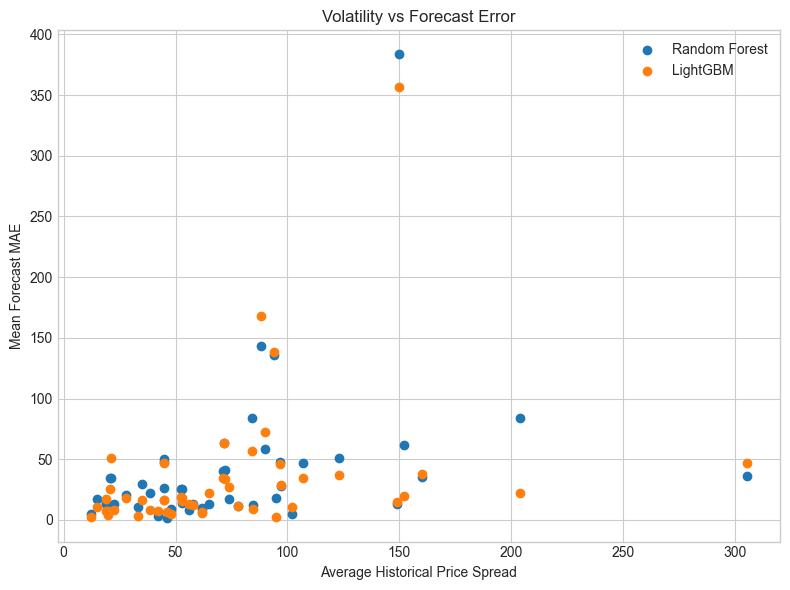

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(volatile_analysis["Mean_Price_Spread"], volatile_analysis["RF_Mean_MAE"], label="Random Forest")
plt.scatter(volatile_analysis["Mean_Price_Spread"], volatile_analysis["LightGBM_Mean_MAE"], label="LightGBM")
plt.xlabel("Average Historical Price Spread"); plt.ylabel("Mean Forecast MAE")
plt.title("Volatility vs Forecast Error"); plt.legend(); plt.tight_layout()
plt.savefig("plots/volatility_vs_forecast_error.png", dpi=300, bbox_inches="tight")
plt.show()

### SHAP — Refit LightGBM With Saved Best Params
Same tuned hyperparameters as Notebook 05 (Section 8), trained on Month 1–8 — no Optuna re-run needed.

In [9]:
lgb_shap_model = MultiOutputRegressor(lgb.LGBMRegressor(**lgb_params))
lgb_shap_model.fit(X_train, y_train)
print("Refit complete:", [type(e).__name__ for e in lgb_shap_model.estimators_])

Refit complete: ['LGBMRegressor', 'LGBMRegressor', 'LGBMRegressor']


#### 1.  SHAP — Global Importance (Bar) Per Target
TreeExplainer is run on the **validation month (Month 9 → 10)** — the held-out month with known actuals — not on training data, so the explanation reflects real generalisation behaviour.

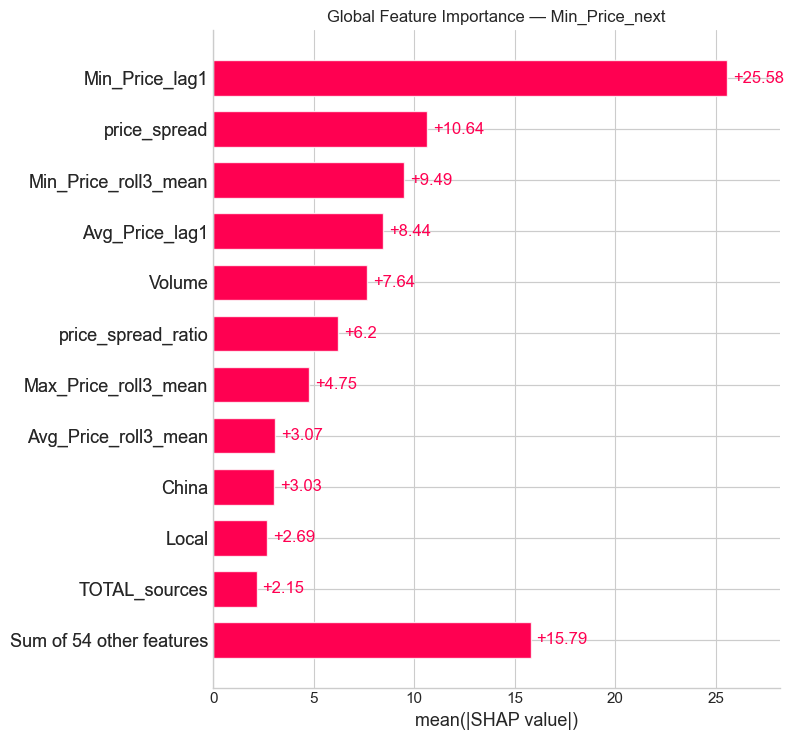

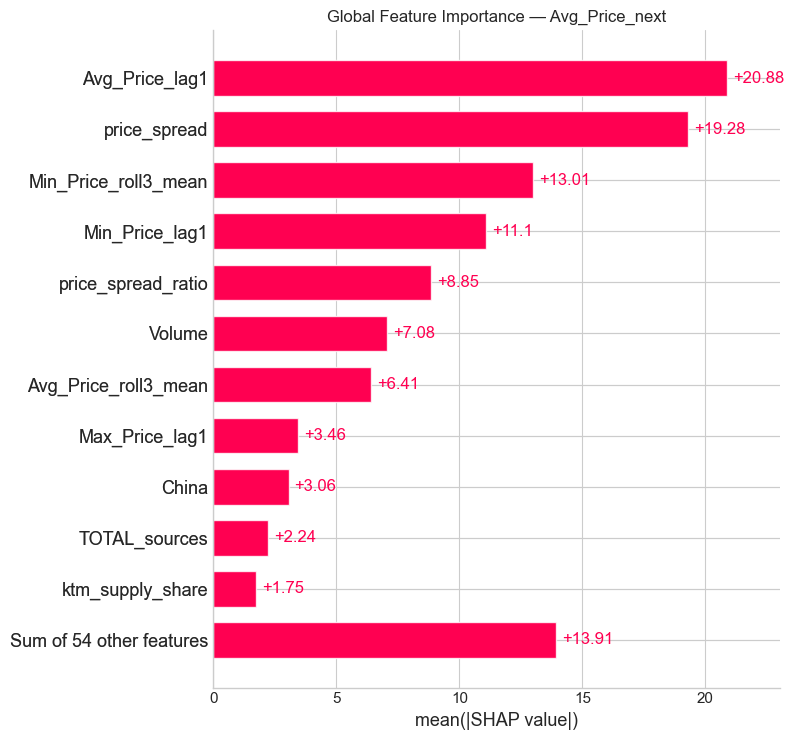

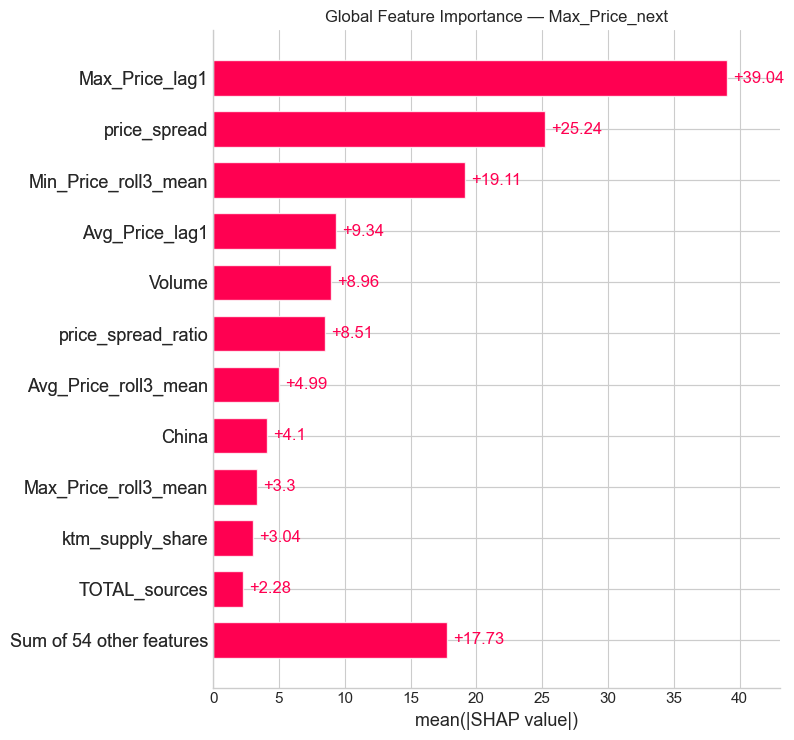

In [10]:
shap_values = {}
for name, est in zip(["min", "avg", "max"], lgb_shap_model.estimators_):
    shap_values[name] = shap.TreeExplainer(est)(X_valid)

for name in ["min", "avg", "max"]:
    plt.figure()
    shap.plots.bar(shap_values[name], show=False, max_display=12)
    plt.title(f"Global Feature Importance — {name.capitalize()}_Price_next")
    plt.tight_layout()
    plt.savefig(f"plots/shap_bar_{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

**Interpretation:** Across all three targets, `Avg_Price_lag1` and the `price_spread`-related features carry the largest mean |SHAP| contribution, meaning the model leans heavily on last month's own price level to set next month's floor, centre and ceiling. Supply-side features (`Volume`, `n_months_present`, district shares) contribute less but shift the ranking between Min, Avg and Max — Max is comparatively more sensitive to volume swings than Min.

#### 2. SHAP — Beeswarm Per Target

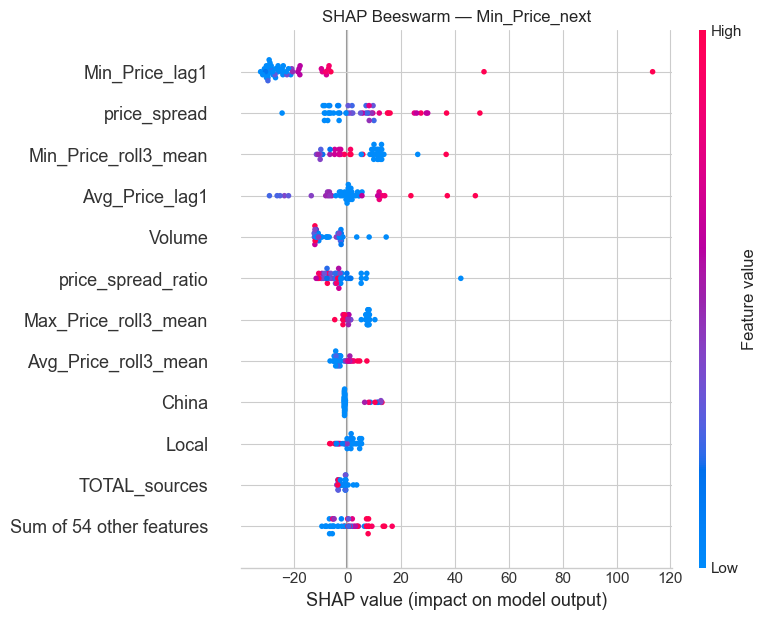

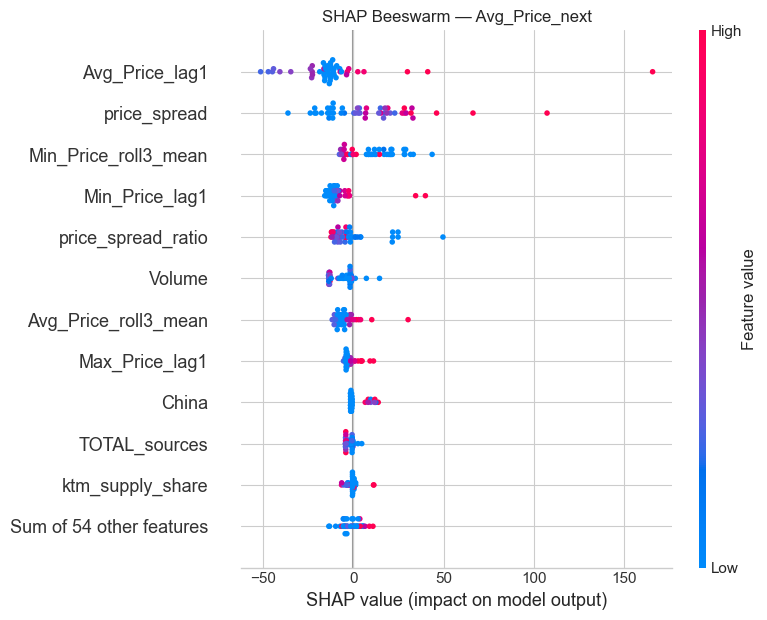

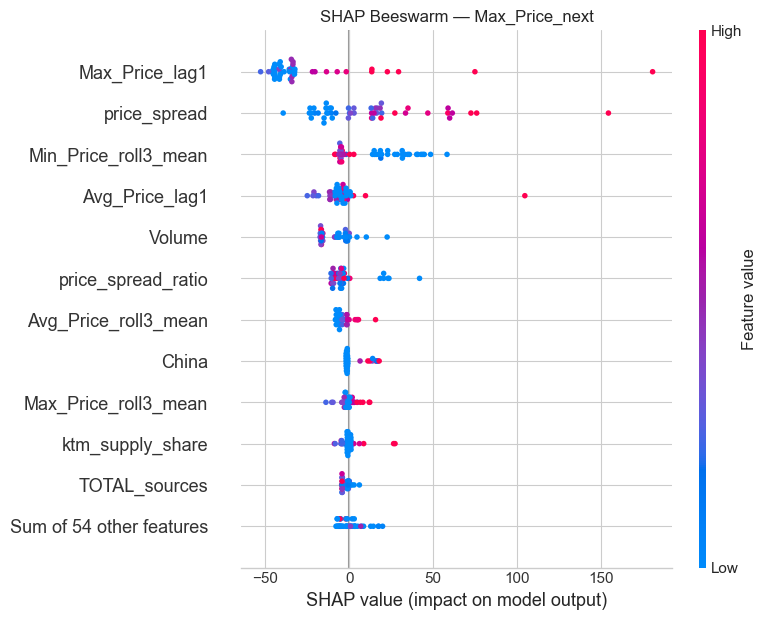

In [11]:
for name in ["min", "avg", "max"]:
    plt.figure()
    shap.plots.beeswarm(shap_values[name], show=False, max_display=12)
    plt.title(f"SHAP Beeswarm — {name.capitalize()}_Price_next")
    plt.tight_layout()
    plt.savefig(f"plots/shap_beeswarm_{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

**Interpretation:** High values of `Avg_Price_lag1` push all three next-month predictions upward (red points sit on the positive-SHAP side for every target), confirming price momentum rather than mean reversion over this short window. The Min-price model shows a tighter, more symmetric SHAP spread than Max, consistent with Max being the more volatile, harder-to-pin-down target. This is an association the model has learned, not a causal claim about what drives prices.

#### 3 SHAP — Dependence Plot
`price_spread_lag1` (last month's Max − Min) vs its effect on next month's Average price.

<Figure size 640x480 with 0 Axes>

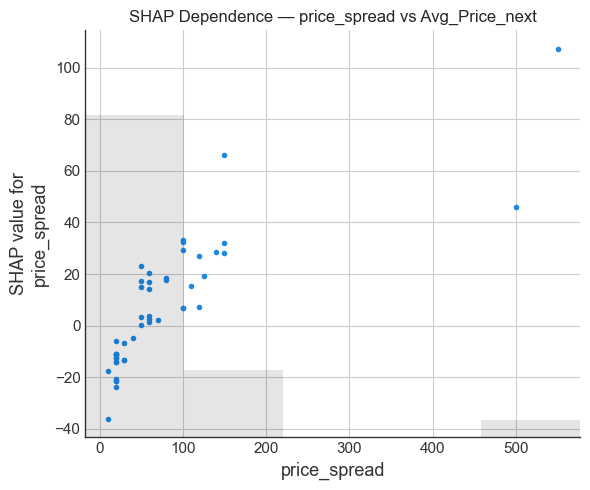

In [12]:
plt.figure()
shap.plots.scatter(shap_values["avg"][:, "price_spread"], show=False)
plt.title("SHAP Dependence — price_spread vs Avg_Price_next")
plt.tight_layout()
plt.savefig("plots/shap_dependence_price_spread_avg.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** A wider historical price spread is associated with a positive SHAP contribution to next month's average price — products that already trade across a wide Min–Max band tend to be pushed toward a higher forecast, likely because spread correlates with scarcity-driven products (fruits, imports). The relationship flattens at very high spread values, suggesting the model saturates rather than extrapolating linearly for the most volatile products.

#### 4 SHAP — Local Waterfall (Single Product)
Explains one individual validation-month prediction end-to-end.

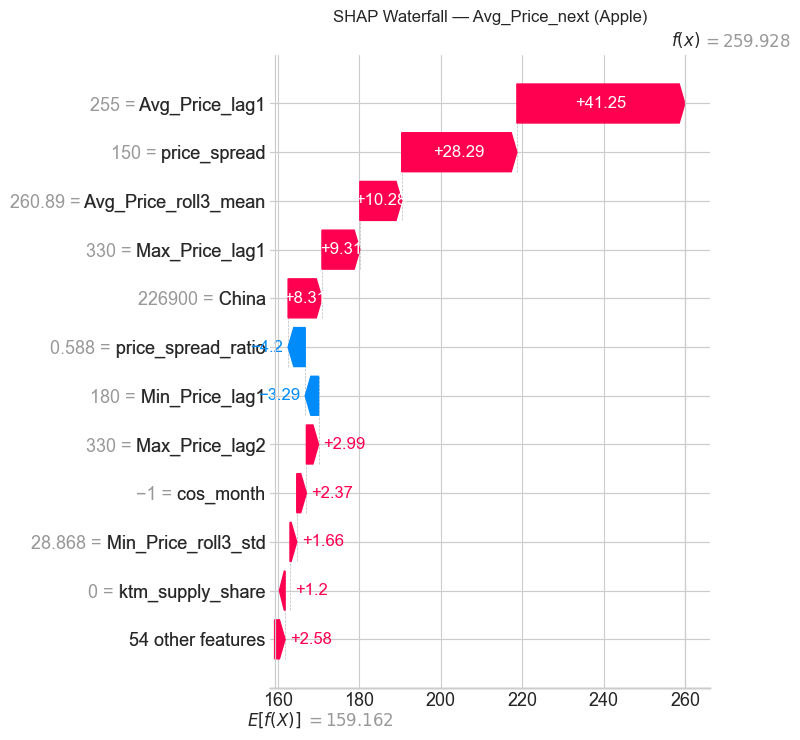

In [13]:
row_idx = 0
product_name = valid_df.iloc[row_idx]["Product_Name"]

plt.figure()
shap.plots.waterfall(shap_values["avg"][row_idx], show=False, max_display=12)
plt.title(f"SHAP Waterfall — Avg_Price_next ({product_name})")
plt.tight_layout()
plt.savefig("plots/shap_waterfall_avg_example.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** For this product, the prediction moves away from the model's base value mainly because of its own `Avg_Price_lag1` and `Min_Price_roll3_mean` — both push the forecast up — while `n_months_present` pulls it slightly down, reflecting a shorter observed history for that product. The waterfall shows the exact additive path from base rate to final forecast for this one row, which the global bar/beeswarm plots average away.

12. Summary

In [14]:
print("ERROR ANALYSIS & SHAP SUMMARY")
print(f"Category-wise error saved : results/category_wise_error.csv")
print(f"Unit-wise error saved     : results/unit_wise_error.csv")
print(f"Volatility analysis saved : results/volatile_product_analysis.csv")
print(f"SHAP artefacts saved      : plots/shap_bar_*.png, shap_beeswarm_*.png,")
print(f"                            shap_dependence_price_spread_avg.png, shap_waterfall_avg_example.png")
print("\nLimitation: only 10 monthly time points are available per product, so seasonal/")
print("cyclical SHAP patterns (e.g. festival effects) should be treated as indicative, not confirmed.")
print("\n✓ ERROR ANALYSIS & SHAP NOTEBOOK COMPLETE")

ERROR ANALYSIS & SHAP SUMMARY
Category-wise error saved : results/category_wise_error.csv
Unit-wise error saved     : results/unit_wise_error.csv
Volatility analysis saved : results/volatile_product_analysis.csv
SHAP artefacts saved      : plots/shap_bar_*.png, shap_beeswarm_*.png,
                            shap_dependence_price_spread_avg.png, shap_waterfall_avg_example.png

Limitation: only 10 monthly time points are available per product, so seasonal/
cyclical SHAP patterns (e.g. festival effects) should be treated as indicative, not confirmed.

✓ ERROR ANALYSIS & SHAP NOTEBOOK COMPLETE
